### Step 1: Import Necessary Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

### Step 2: Load the Iris Dataset

In [7]:
# Load the Iris dataset
iris = sns.load_dataset('iris')

# Remove species column since clustering is unsupervised
iris_data = iris.drop('species', axis=1)

### Step 3: Standardize the Data

In [8]:
scaler = StandardScaler()
scaled_iris = scaler.fit_transform(iris_data)

### Step 4: Find the Optimal Number of Clusters(Elbow Method)

c:\Users\25473\anaconda3\envs\ml-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\25473\anaconda3\envs\ml-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\25473\anaconda3\envs\ml-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\25473\anaconda3\envs\ml-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning:

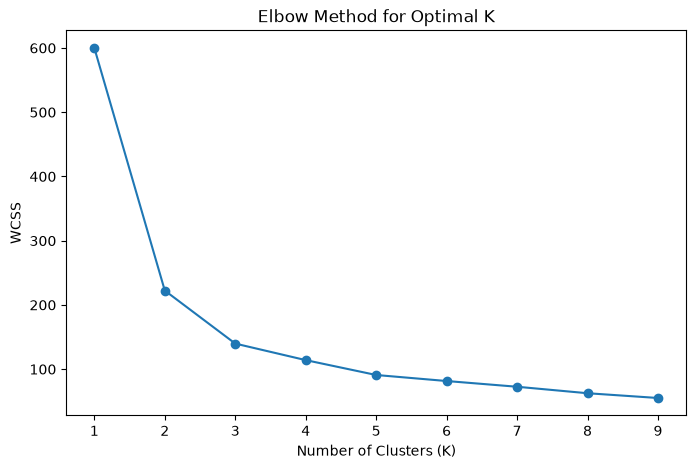

In [9]:
# Determine the optimal number of clusters using the Elbow Method
wcss = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_iris)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(1, 10), wcss, marker='o', linestyle='-')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

### Step 5: Apply K-Means Clustering

In [10]:
optimal_k = 3  # Based on the Elbow Method
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
iris_data['cluster'] = kmeans.fit_predict(scaled_iris)

c:\Users\25473\anaconda3\envs\ml-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### Step 6: Validate Clustering with Silhoutte Score

In [12]:
# Validate clustering with Silhouette Score
silhouette_avg = silhouette_score(scaled_iris, iris_data['cluster'])
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.45994823920518646


### Step 7: Visualize Clusters Using PCA

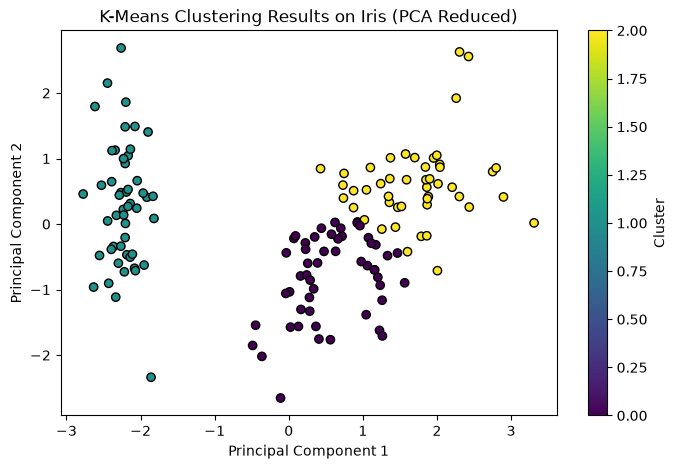

In [14]:
pca = PCA(n_components=2)
iris_pca = pca.fit_transform(scaled_iris)

# Scatter plot of clusters
plt.figure(figsize=(8,5))
plt.scatter(iris_pca[:, 0], iris_pca[:, 1], c=iris_data["cluster"], cmap='viridis', marker='o', edgecolor='k')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering Results on Iris (PCA Reduced)")
plt.colorbar(label="Cluster")
plt.show()

### Step 8: Analyze Cluster Properties

In [15]:
cluster_means = iris_data.groupby('cluster').mean()
print("Cluster Means:\n", cluster_means)

Cluster Means:
          sepal_length  sepal_width  petal_length  petal_width
cluster                                                      
0            5.801887     2.673585      4.369811     1.413208
1            5.006000     3.428000      1.462000     0.246000
2            6.780851     3.095745      5.510638     1.972340


### Step 9: Compare Clusters with Actual Species Labels

In [16]:
iris['Predicted Cluster'] = iris_data['cluster']
print(iris.groupby(["species", "Predicted Cluster"]).size())

species     Predicted Cluster
setosa      1                    50
versicolor  0                    39
            2                    11
virginica   0                    14
            2                    36
dtype: int64
